In [3]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import rasterio

plt.style.use("ggplot")


In [4]:
RGB_DIR = "../EuroSAT_Dataset/EuroSAT"
MS_DIR = "../EuroSAT_Dataset/EuroSATallBands"

TRAIN_CSV = "../EuroSAT_Dataset/train.csv"
VAL_CSV = "../EuroSAT_Dataset/validation.csv"

FIGURE_DIR = "../outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Train samples :", len(train_df))
print("Validation samples :", len(val_df))

train_df.head()

Train samples : 18900
Validation samples : 4050


,filename,label,classname
0,AnnualCrop\AnnualCrop_683.jpg,0,AnnualCrop
1,AnnualCrop\AnnualCrop_2035.jpg,0,AnnualCrop
2,AnnualCrop\AnnualCrop_842.jpg,0,AnnualCrop
3,AnnualCrop\AnnualCrop_1092.jpg,0,AnnualCrop
4,AnnualCrop\AnnualCrop_1327.jpg,0,AnnualCrop


In [6]:
classes = sorted(os.listdir(os.path.join(RGB_DIR, "train")))

train_count = 0
val_count = 0

for cls in classes:
    train_count += len(os.listdir(os.path.join(RGB_DIR, "train", cls)))
    val_count += len(os.listdir(os.path.join(RGB_DIR, "val", cls)))

test_count = len(os.listdir("../EuroSAT_Dataset/EuroSAT_test_flat"))

overview = pd.DataFrame({
    "Split":["Train","Validation","Test"],
    "Samples":[train_count,val_count,test_count]
})

In [7]:
print("Dataset Overview")
print("-"*40)

print(f"Train Samples      : {train_count}")
print(f"Validation Samples : {val_count}")
print(f"Test Samples       : {test_count}")

Dataset Overview
----------------------------------------
Train Samples      : 18900
Validation Samples : 4050
Test Samples       : 4050


In [8]:
train_dist = {}
val_dist = {}

for cls in classes:
    train_dist[cls] = len(os.listdir(os.path.join(RGB_DIR,"train",cls)))
    val_dist[cls] = len(os.listdir(os.path.join(RGB_DIR,"val",cls)))

train_dist

{'AnnualCrop': 2100,
 'Forest': 2100,
 'HerbaceousVegetation': 2100,
 'Highway': 1750,
 'Industrial': 1750,
 'Pasture': 1400,
 'PermanentCrop': 1750,
 'Residential': 2100,
 'River': 1750,
 'SeaLake': 2100}

In [9]:
val_dist

{'AnnualCrop': 450,
 'Forest': 450,
 'HerbaceousVegetation': 450,
 'Highway': 375,
 'Industrial': 375,
 'Pasture': 300,
 'PermanentCrop': 375,
 'Residential': 450,
 'River': 375,
 'SeaLake': 450}

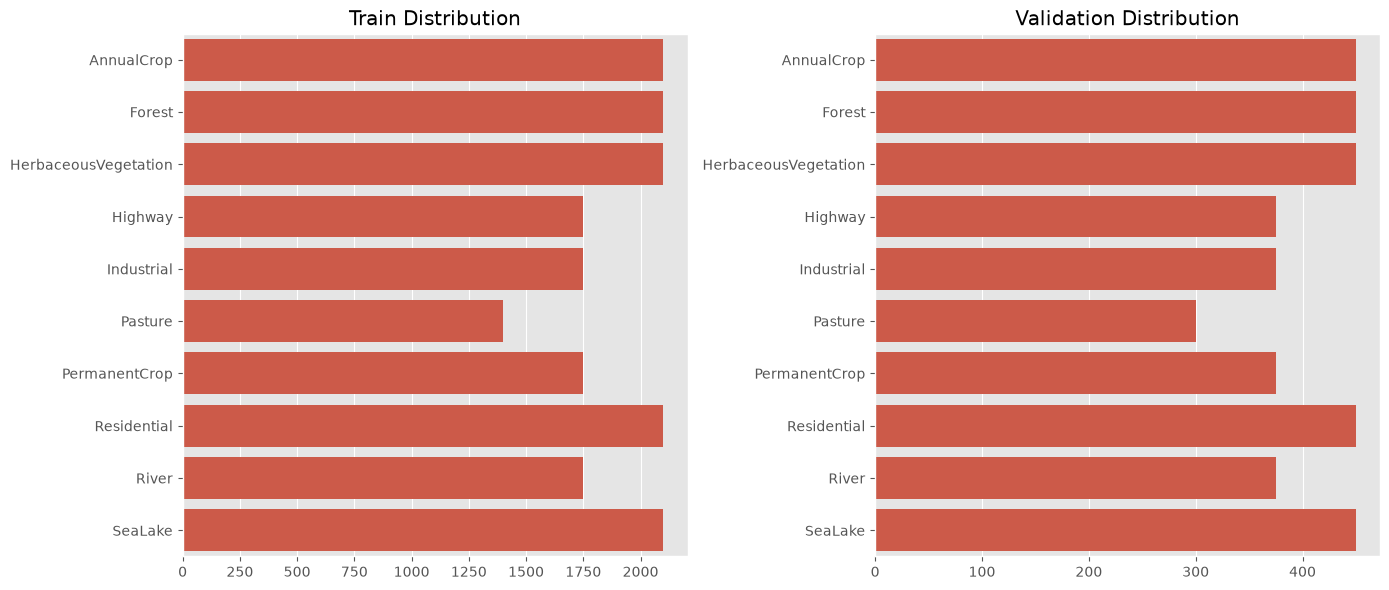

In [10]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.barplot(
    x=list(train_dist.values()),
    y=list(train_dist.keys()),
    ax=axes[0]
)

axes[0].set_title("Train Distribution")

sns.barplot(
    x=list(val_dist.values()),
    y=list(val_dist.keys()),
    ax=axes[1]
)

axes[1].set_title("Validation Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR,"class_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

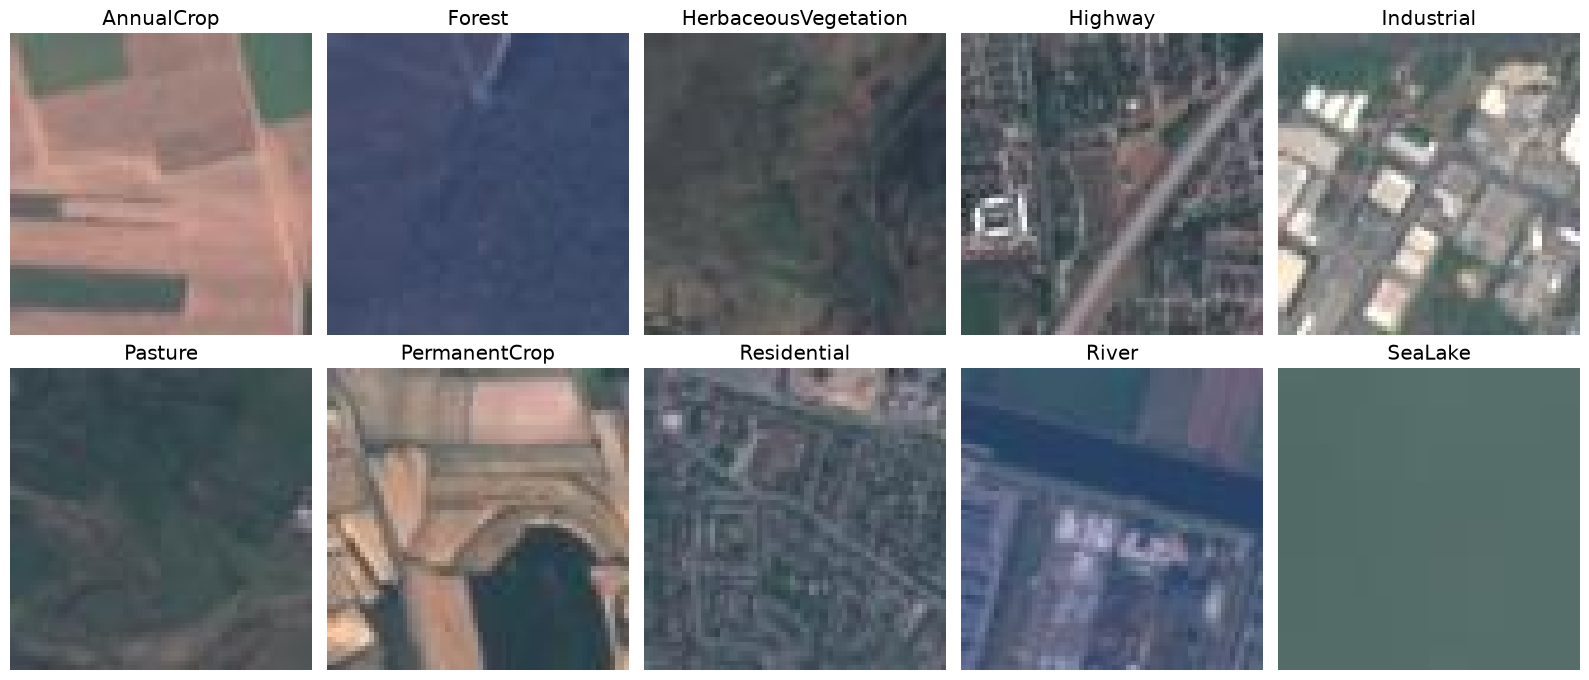

In [11]:
fig, axes = plt.subplots(2,5, figsize=(16,7))

axes = axes.flatten()

for idx, cls in enumerate(classes):

    img_path = os.path.join(
        RGB_DIR,
        "train",
        cls,
        random.choice(
            os.listdir(
                os.path.join(RGB_DIR,"train",cls)
            )
        )
    )

    img = Image.open(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(cls)
    axes[idx].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR,"sample_rgb_images.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
rgb_stats = []

for cls in classes:

    files = os.listdir(
        os.path.join(RGB_DIR,"train",cls)
    )[:100]

    r,g,b = [],[],[]

    for file in files:

        img = np.array(
            Image.open(
                os.path.join(
                    RGB_DIR,
                    "train",
                    cls,
                    file
                )
            )
        )

        r.append(img[:,:,0].mean())
        g.append(img[:,:,1].mean())
        b.append(img[:,:,2].mean())

    rgb_stats.append([
        cls,
        np.mean(r),
        np.mean(g),
        np.mean(b)
    ])

rgb_df = pd.DataFrame(
    rgb_stats,
    columns=["Class","Red","Green","Blue"]
)

rgb_df

,Class,Red,Green,Blue
0,AnnualCrop,115.316934,106.498704,104.936902
1,Forest,34.545093,57.069229,67.965579
2,HerbaceousVegetation,87.192180,88.066299,93.123950
3,Highway,82.613425,88.738816,94.035396
4,Industrial,111.925259,114.173481,121.819717
5,Pasture,55.480015,79.026079,84.026189
6,PermanentCrop,111.333948,106.367852,103.931499
7,Residential,86.716292,91.399827,100.438711
8,River,59.470842,77.993726,87.800146
9,SeaLake,41.006685,63.045664,78.316045


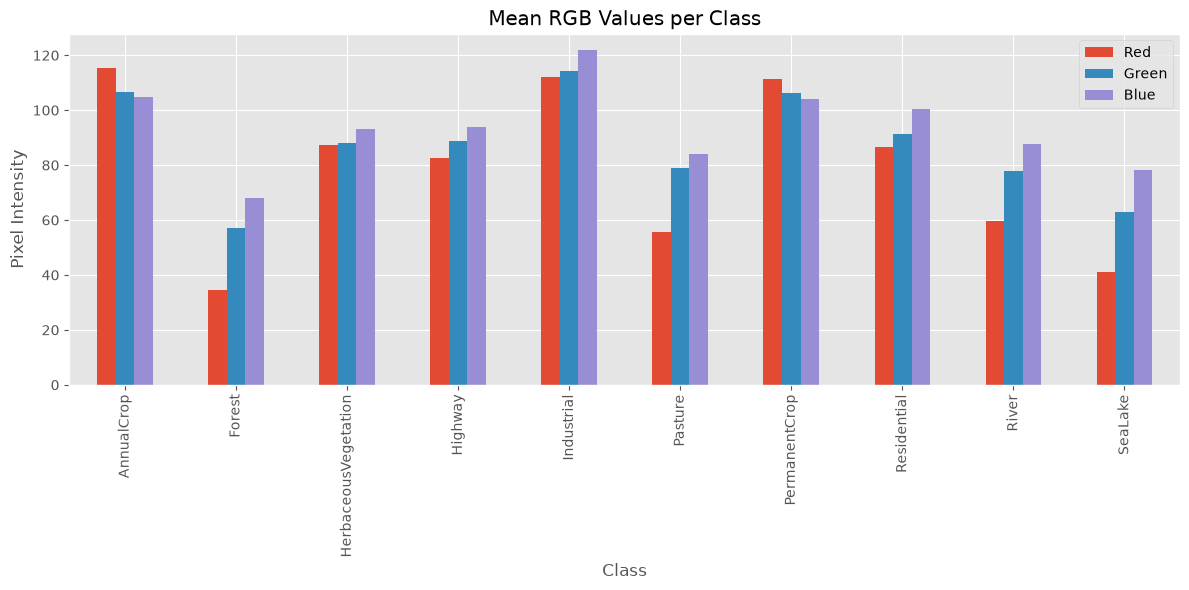

In [13]:
rgb_df.set_index("Class").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Mean RGB Values per Class")
plt.ylabel("Pixel Intensity")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR,"rgb_means_per_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
sample_class = classes[0]

sample_tif = os.path.join(
    MS_DIR,
    "train",
    sample_class,
    os.listdir(
        os.path.join(
            MS_DIR,
            "train",
            sample_class
        )
    )[0]
)

with rasterio.open(sample_tif) as src:
    bands = src.read()

print("Shape:", bands.shape)

Shape: (13, 64, 64)


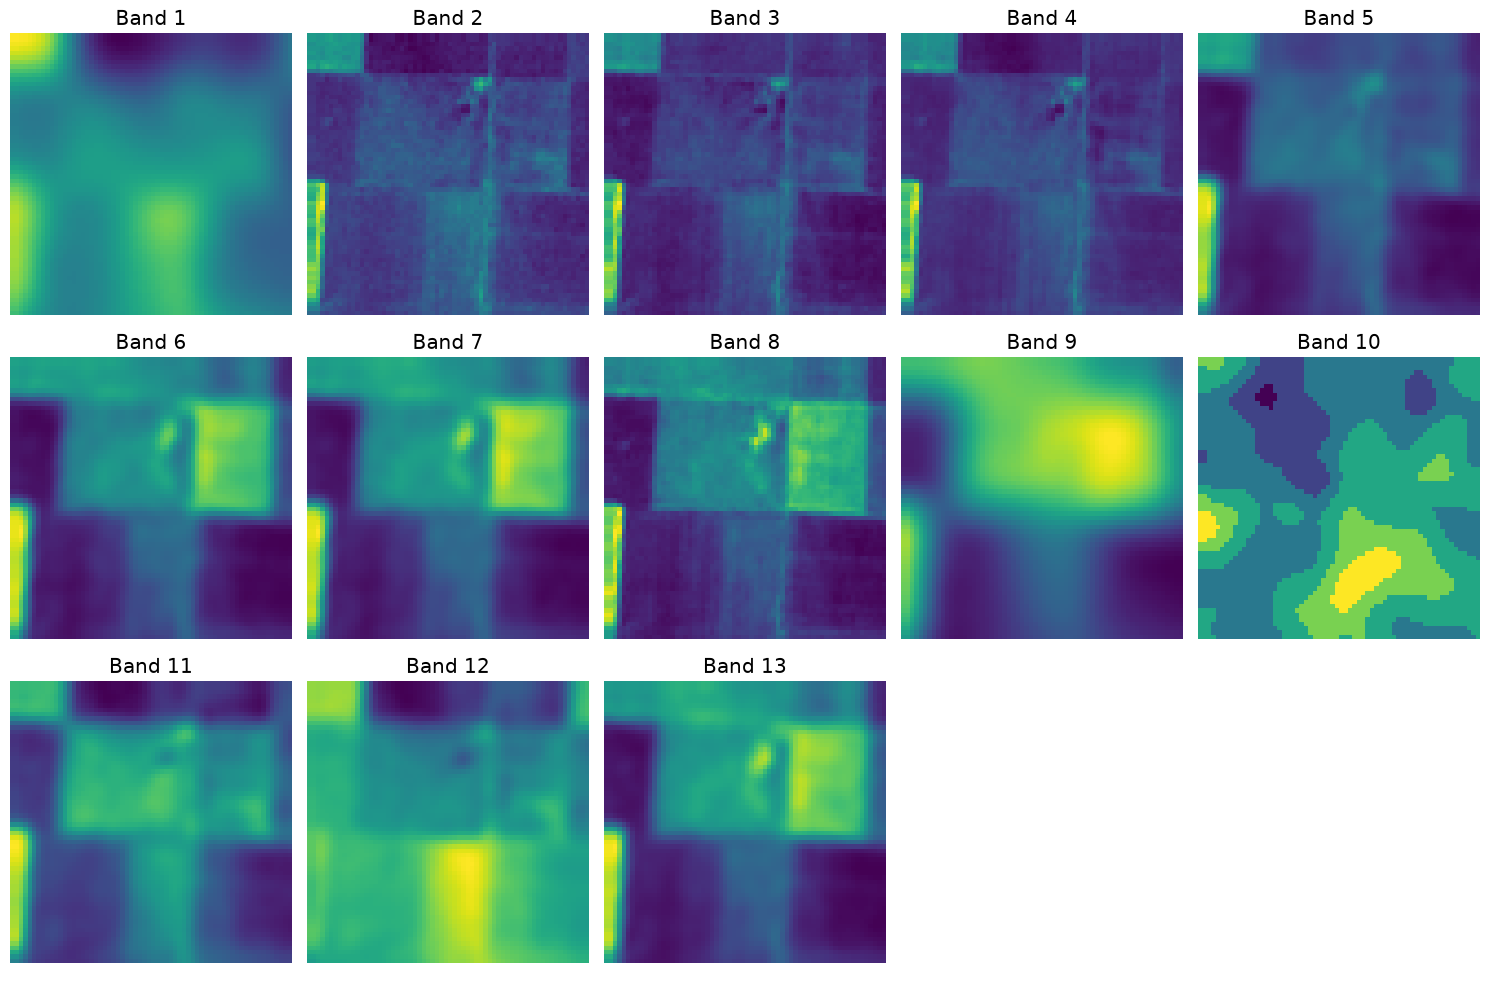

In [15]:
fig, axes = plt.subplots(3,5, figsize=(15,10))

axes = axes.flatten()

for i in range(13):

    axes[i].imshow(
        bands[i],
        cmap="viridis"
    )

    axes[i].set_title(f"Band {i+1}")
    axes[i].axis("off")

for i in range(13,15):
    axes[i].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR,"multispectral_bands.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
spectral_signatures = {}

for cls in classes:

    tif_files = os.listdir(
        os.path.join(
            MS_DIR,
            "train",
            cls
        )
    )[:30]

    class_band_mean = []

    for file in tif_files:

        with rasterio.open(
            os.path.join(
                MS_DIR,
                "train",
                cls,
                file
            )
        ) as src:

            img = src.read()

            class_band_mean.append(
                img.mean(axis=(1,2))
            )

    spectral_signatures[cls] = np.mean(
        class_band_mean,
        axis=0
    )

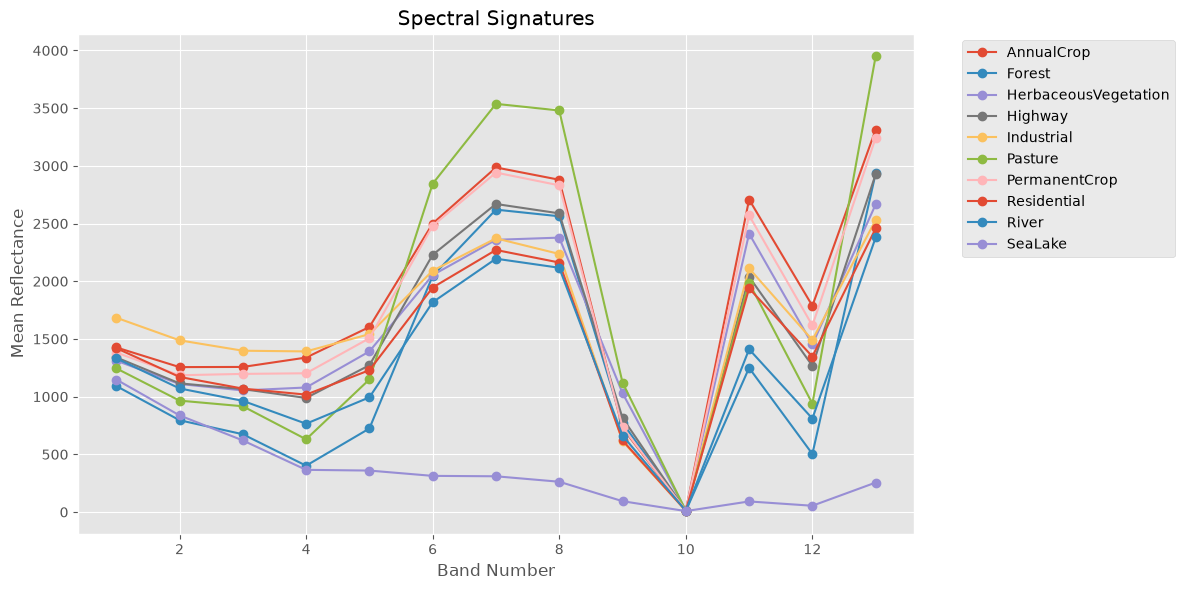

In [17]:
plt.figure(figsize=(12,6))

for cls, sig in spectral_signatures.items():

    plt.plot(
        range(1,14),
        sig,
        marker="o",
        label=cls
    )

plt.xlabel("Band Number")
plt.ylabel("Mean Reflectance")
plt.title("Spectral Signatures")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR,"spectral_signatures.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
def calculate_indices(img):

    nir = img[7].astype(float)
    green = img[2].astype(float)
    swir = img[11].astype(float)

    ndvi = (nir-green)/(nir+green+1e-6)

    ndwi = (green-nir)/(green+nir+1e-6)

    ndbi = (swir-nir)/(swir+nir+1e-6)

    return ndvi, ndwi, ndbi

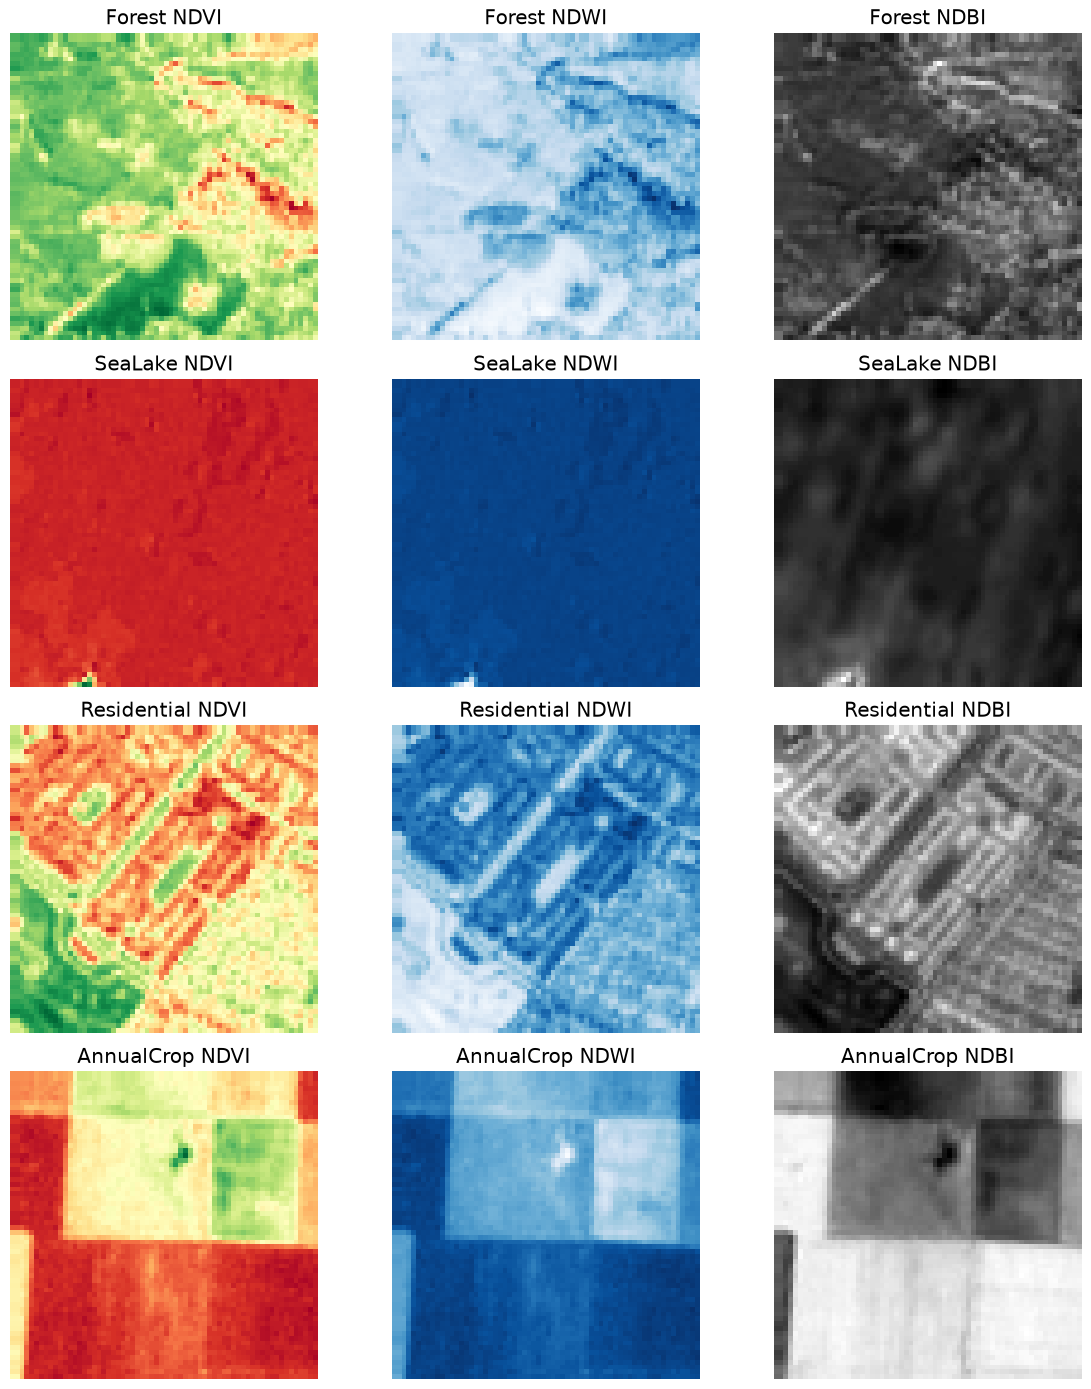

In [19]:
selected_classes = [
    "Forest",
    "SeaLake",
    "Residential",
    "AnnualCrop"
]

fig, axes = plt.subplots(4,3, figsize=(12,14))

for row, cls in enumerate(selected_classes):

    tif_path = os.path.join(
        MS_DIR,
        "train",
        cls,
        os.listdir(
            os.path.join(
                MS_DIR,
                "train",
                cls
            )
        )[0]
    )

    with rasterio.open(tif_path) as src:
        img = src.read()

    ndvi, ndwi, ndbi = calculate_indices(img)

    axes[row,0].imshow(ndvi,cmap="RdYlGn")
    axes[row,0].set_title(f"{cls} NDVI")

    axes[row,1].imshow(ndwi,cmap="Blues")
    axes[row,1].set_title(f"{cls} NDWI")

    axes[row,2].imshow(ndbi,cmap="gray")
    axes[row,2].set_title(f"{cls} NDBI")

    for col in range(3):
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

In [20]:
plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "spectral_indices_preview.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>